In [1]:
# ==========================================================
# IMPORTS
# ==========================================================
# Manipulation des données
import pandas as pd
import numpy as np
# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
# Reproductibilité
import random
# ==========================================================
# CONFIGURATION
# ==========================================================
# Seed utilisée dans tout le projet
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
# Affichage des graphiques dans Jupyter Notebook
%matplotlib inline
# Style des graphiques
sns.set_theme(style="whitegrid", palette="deep")
# Taille par défaut des figures
plt.rcParams["figure.figsize"] = (10, 6)
# Taille des polices
plt.rcParams["font.size"] = 12
# Affichage complet des colonnes Pandas
pd.set_option("display.max_columns", None)
# Affichage complet des lignes (à utiliser avec prudence sur de grands datasets)
pd.set_option("display.max_rows", 100)
# Largeur maximale d'affichage
pd.set_option("display.width", 120)
# Nombre de décimales affichées
pd.set_option("display.precision", 2)
print("Environment setup complete.")

Environment setup complete.


In [2]:
df = pd.read_csv("../data/raw/diabetic_data.csv", na_values="?")
print("aperçu des 5 premières lignes du dataset :")
display(df.head())

C:\Users\malek\AppData\Local\Temp\ipykernel_20300\565678002.py:1: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/diabetic_data.csv", na_values="?")


aperçu des 5 premières lignes du dataset :


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
print("aperçu des 5 dernières lignes du dataset :")
display(df.tail())

print("échantillon de 5 lignes aléatoires du dataset :")
display(df.sample(5, random_state=SEED))


aperçu des 5 dernières lignes du dataset :


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,MC,NaN,51,0,16,0,0,0,250.13,291,458,9,NaN,>8,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,MC,NaN,33,3,18,0,0,1,560,276,787,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,MC,NaN,53,0,9,1,0,0,38,590,296,13,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,MC,Surgery-General,45,2,21,0,0,1,996,285,998,9,NaN,NaN,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),NaN,1,1,7,6,NaN,NaN,13,3,3,0,0,0,530,530,787,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO


échantillon de 5 lignes aléatoires du dataset :


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
35956,110939484,19274094,Caucasian,Female,[70-80),NaN,1,1,6,11,UN,InternalMedicine,68,0,20,0,0,0,250.8,599,263,5,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
60927,170328306,65634327,Caucasian,Male,[50-60),NaN,1,1,1,1,HM,NaN,20,0,7,0,0,0,780,427,E941,8,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
79920,245688426,100657359,Caucasian,Female,[60-70),NaN,3,6,1,4,HM,NaN,21,3,23,1,0,2,715,733,724,7,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
50078,150826224,83144448,Caucasian,Male,[30-40),NaN,2,1,1,12,CP,Gastroenterology,28,0,19,0,0,1,494,277,117,7,NaN,NaN,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,>30
44080,135993852,65234214,AfricanAmerican,Female,[60-70),NaN,1,2,7,1,NaN,NaN,21,0,6,0,0,0,403,584,428,7,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,<30


In [4]:
print(f"Nombre de lignes    : {df.shape[0]}")
print(f"Nombre de colonnes  : {df.shape[1]}")

Nombre de lignes    : 101766
Nombre de colonnes  : 50


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [6]:
# =============================================================
# DÉTECTION DES DOUBLONS
# =============================================================

# --- Doublons sur toutes les colonnes ---
nb_doublons = df.duplicated().sum()
print(f"Doublons exacts (toutes colonnes) : {nb_doublons}")

# --- Doublons sur encounter_id ---
# encounter_id = identifiant unique d'un séjour hospitalier
# Si deux lignes ont le même encounter_id → problème de données
nb_doublons_id = df.duplicated(subset=["encounter_id"]).sum()
print(f"Doublons sur encounter_id          : {nb_doublons_id}")

# --- Doublons sur patient_nbr ---
# Un même patient peut avoir PLUSIEURS séjours
# Ce n'est pas un doublon, c'est une réalité médicale
nb_patients_uniques = df["patient_nbr"].nunique()
nb_sejours_total    = len(df)

print(f"\nPatients uniques  : {nb_patients_uniques:,}")
print(f"Séjours totaux    : {nb_sejours_total:,}")
print(f"Séjours par patient (moyenne) : "
      f"{nb_sejours_total/nb_patients_uniques:.2f}")

Doublons exacts (toutes colonnes) : 0
Doublons sur encounter_id          : 0

Patients uniques  : 71,518
Séjours totaux    : 101,766
Séjours par patient (moyenne) : 1.42


Colonnes avec valeurs manquantes : 9


,Valeurs manquantes,Pourcentage (%)
weight,98569,96.9
max_glu_serum,96420,94.7
A1Cresult,84748,83.3
medical_specialty,49949,49.1
payer_code,40256,39.6
race,2273,2.2
diag_3,1423,1.4
diag_2,358,0.4
diag_1,21,0.0


Pourcentage global manquant : 7.35%


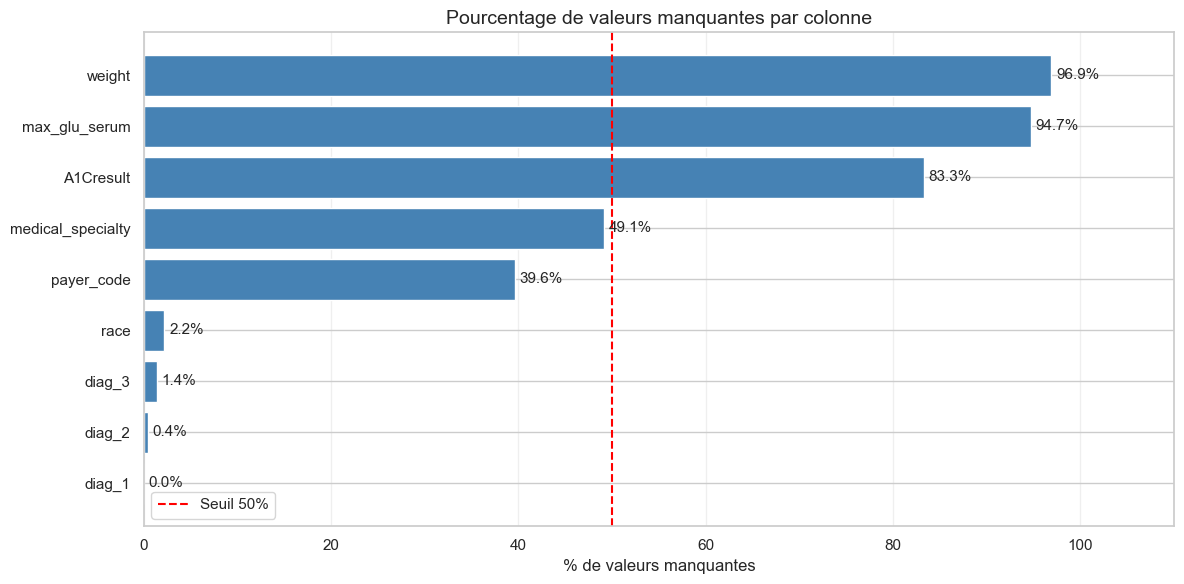

In [7]:
# =============================================================
# VALEURS MANQUANTES
# =============================================================

# --- Calcul ---
missing_data    = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_data / len(df) * 100).round(1)
missing_summary = pd.DataFrame({
    "Valeurs manquantes" : missing_data,
    "Pourcentage (%)"    : missing_percent
})
missing_summary = missing_summary[missing_summary["Valeurs manquantes"] > 0]

# --- Tableau résumé ---
print(f"Colonnes avec valeurs manquantes : {len(missing_summary)}")
display(missing_summary)

# --- Pourcentage global ---
total_cellules  = df.shape[0] * df.shape[1]
total_manquants = df.isnull().sum().sum()
pct_global      = (total_manquants / total_cellules * 100).round(2)
print(f"Pourcentage global manquant : {pct_global}%")

# --- Visualisation ---
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(missing_summary.index[::-1],
               missing_summary["Pourcentage (%)"][::-1],
               color="steelblue", edgecolor="white")

ax.axvline(x=50, color="red", linestyle="--",
           linewidth=1.5, label="Seuil 50%")

for bar, pct in zip(bars, missing_summary["Pourcentage (%)"][::-1]):
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"{pct}%", va="center", fontsize=11)

ax.set_title("Pourcentage de valeurs manquantes par colonne",
             fontsize=14)
ax.set_xlabel("% de valeurs manquantes")
ax.set_xlim(0, 110)
ax.legend(fontsize=11)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# -----STATISTIQUES DESCRIPTIVES-----
print("=" * 60)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 60)
display(df.describe())

STATISTIQUES DESCRIPTIVES


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.02e+05,1.02e+05,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,1.65e+08,5.43e+07,2.02,3.72,5.75,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,1.03e+08,3.87e+07,1.45,5.28,4.06,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,1.25e+04,1.35e+02,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,8.50e+07,2.34e+07,1.00,1.00,1.00,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,1.52e+08,4.55e+07,1.00,1.00,7.00,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,2.30e+08,8.75e+07,3.00,4.00,7.00,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,4.44e+08,1.90e+08,8.00,28.00,25.00,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


DISTRIBUTION DE LA VARIABLE CIBLE
  NO     : 54,864 patients  (53.9%)
  >30    : 35,545 patients  (34.9%)
  <30    : 11,357 patients  (11.2%)


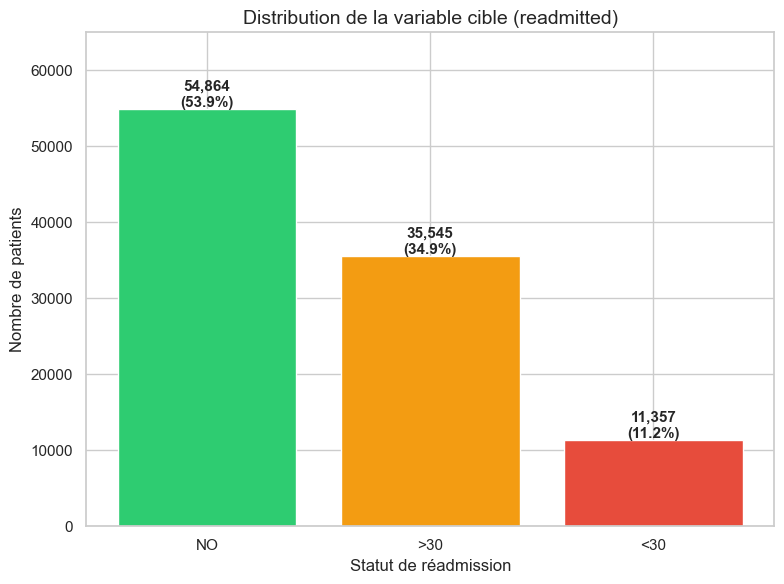

In [9]:
# =============================================================
# CELLULE 6 — DISTRIBUTION DE LA VARIABLE CIBLE
# =============================================================

# La variable cible "readmitted" a 3 valeurs :
# "<30" = réadmis en moins de 30 jours
# ">30" = réadmis après 30 jours
# "NO"  = jamais réadmis

# --- Comptage et pourcentages ---
cible = df["readmitted"].value_counts()
cible_pct = (cible / len(df) * 100).round(1)

print("=" * 45)
print("DISTRIBUTION DE LA VARIABLE CIBLE")
print("=" * 45)
for val, count in cible.items():
    pct = cible_pct[val]
    print(f"  {val:<6} : {count:>6,} patients  ({pct}%)")
print("=" * 45)

# --- Visualisation ---
ordre   = ["NO", ">30", "<30"]
couleurs = ["#2ECC71", "#F39C12", "#E74C3C"]

plt.figure(figsize=(8, 6))
bars = plt.bar(ordre,
               [cible[v] for v in ordre],
               color=couleurs,
               edgecolor="white")

for bar, val in zip(bars, ordre):
    count = cible[val]
    pct   = cible_pct[val]
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 300,
             f"{count:,}\n({pct}%)",
             ha="center", fontsize=11, fontweight="bold")

plt.title("Distribution de la variable cible (readmitted)",
          fontsize=14)
plt.xlabel("Statut de réadmission")
plt.ylabel("Nombre de patients")
plt.ylim(0, 65000)
plt.tight_layout()
plt.show()

DÉSÉQUILIBRE ATTENDU APRÈS BINARISATION
  Classe 0 (non réadmis) : 90,409 (88.8%)
  Classe 1 (réadmis <30) : 11,357 (11.2%)
  Ratio                  : 8.0:1

⚠️ Déséquilibre sévère → nécessitera :
  - scale_pos_weight pour XGBoost
  - class_weight='balanced' pour LR et RF
  - PR-AUC comme métrique principale
  - Recall comme métrique médicale clé


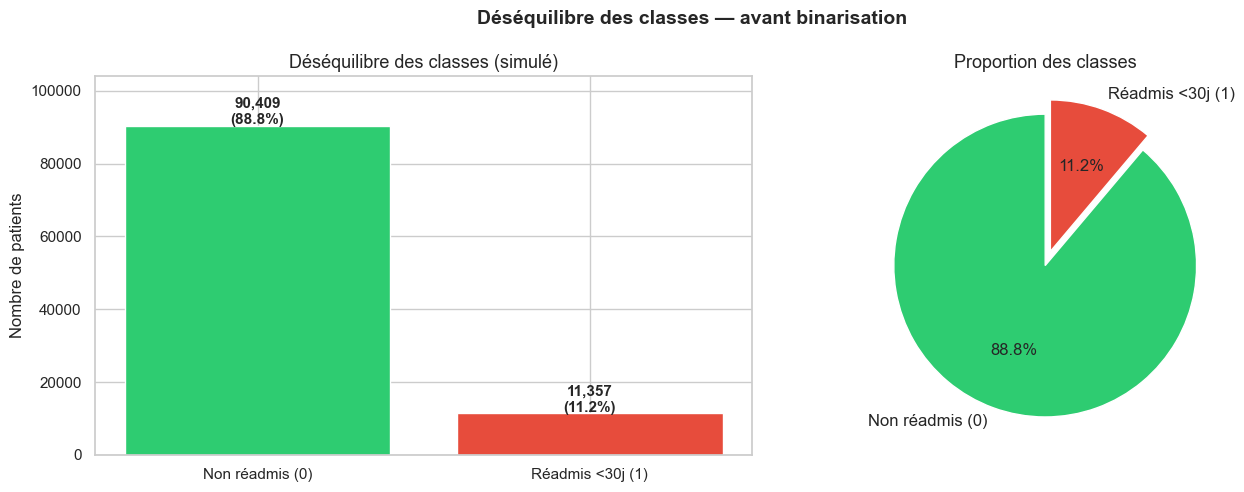

In [10]:
# =============================================================
# CELLULE 7 — ANALYSE DU DÉSÉQUILIBRE DES CLASSES
# =============================================================

# On visualise le déséquilibre ATTENDU après binarisation
# sans modifier df

# Simulation de la distribution binaire
positifs  = (df["readmitted"] == "<30").sum()
negatifs  = (df["readmitted"] != "<30").sum()
total     = len(df)

print("=" * 45)
print("DÉSÉQUILIBRE ATTENDU APRÈS BINARISATION")
print("=" * 45)
print(f"  Classe 0 (non réadmis) : "
      f"{negatifs:,} ({negatifs/total*100:.1f}%)")
print(f"  Classe 1 (réadmis <30) : "
      f"{positifs:,} ({positifs/total*100:.1f}%)")
print(f"  Ratio                  : "
      f"{negatifs/positifs:.1f}:1")
print("=" * 45)
print("\n⚠️ Déséquilibre sévère → nécessitera :")
print("  - scale_pos_weight pour XGBoost")
print("  - class_weight='balanced' pour LR et RF")
print("  - PR-AUC comme métrique principale")
print("  - Recall comme métrique médicale clé")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barres
bars = axes[0].bar(
    ["Non réadmis (0)", "Réadmis <30j (1)"],
    [negatifs, positifs],
    color=["#2ECC71", "#E74C3C"],
    edgecolor="white"
)
for bar, val in zip(bars, [negatifs, positifs]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{val:,}\n({val/total*100:.1f}%)",
        ha="center", fontsize=11, fontweight="bold"
    )
axes[0].set_title("Déséquilibre des classes (simulé)",
                  fontsize=13)
axes[0].set_ylabel("Nombre de patients")
axes[0].set_ylim(0, negatifs * 1.15)

# Camembert
axes[1].pie(
    [negatifs, positifs],
    labels   = ["Non réadmis (0)", "Réadmis <30j (1)"],
    colors   = ["#2ECC71", "#E74C3C"],
    autopct  = "%1.1f%%",
    explode  = (0, 0.1),
    startangle = 90,
    textprops  = {"fontsize": 12}
)
axes[1].set_title("Proportion des classes", fontsize=13)

plt.suptitle("Déséquilibre des classes — avant binarisation",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

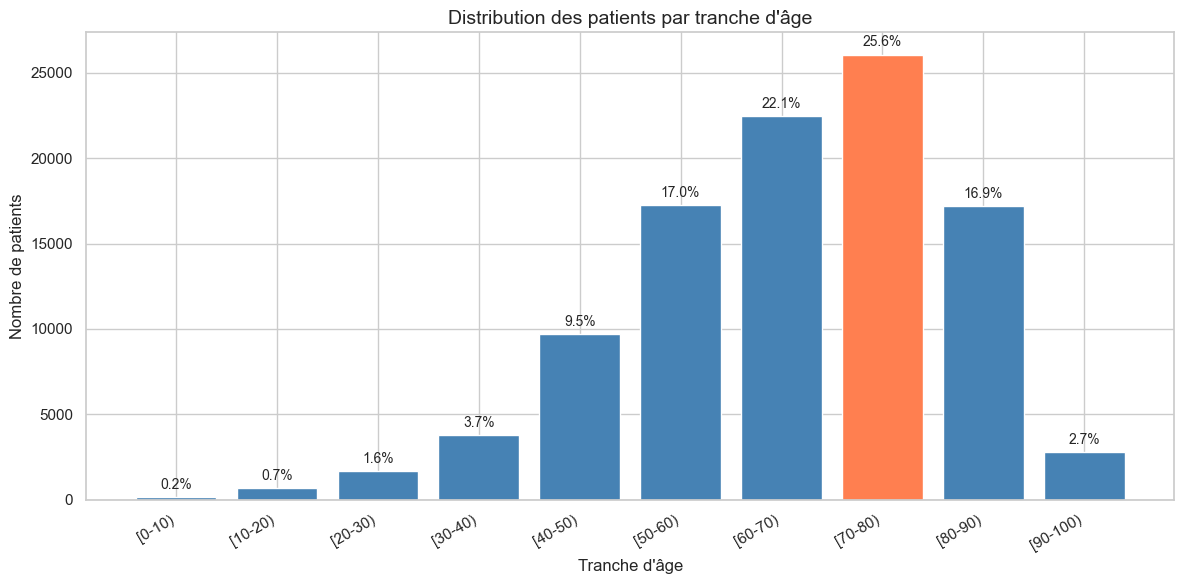

In [11]:
# =============================================================
# CELLULE 8 — DISTRIBUTION DE L'ÂGE
# =============================================================

# L'âge est une variable catégorielle ordonnée
# On la trie chronologiquement pour qu'elle soit lisible
age_order = ["[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
             "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"]

age_counts   = df["age"].value_counts().reindex(age_order)
age_pct      = (age_counts / len(df) * 100).round(1)

# Couleur différente pour la barre dominante
couleurs = ["coral" if age == "[70-80)" else "steelblue"
            for age in age_order]

plt.figure(figsize=(12, 6))
bars = plt.bar(age_order, age_counts.values,
               color=couleurs, edgecolor="white")

for bar, pct in zip(bars, age_pct):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 300,
             f"{pct}%",
             ha="center", va="bottom", fontsize=10)

plt.title("Distribution des patients par tranche d'âge",
          fontsize=14)
plt.xlabel("Tranche d'âge")
plt.ylabel("Nombre de patients")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

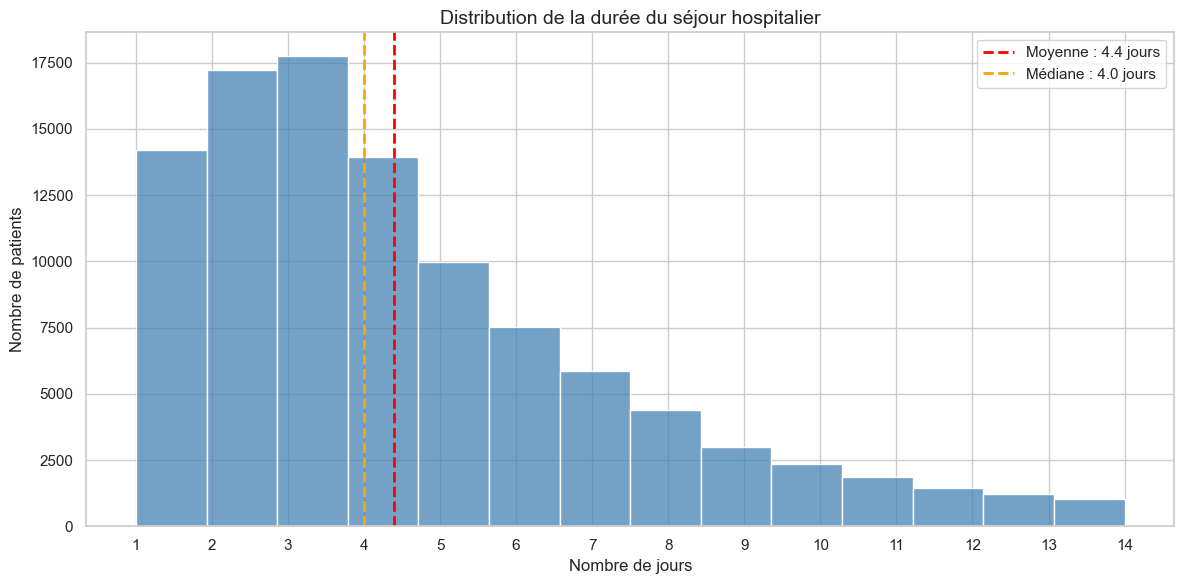

Moyenne  : 4.4 jours
Médiane  : 4.0 jours
Minimum  : 1 jours
Maximum  : 14 jours


In [12]:
# =============================================================
# CELLULE 9 — DISTRIBUTION DE LA DURÉE DU SÉJOUR
# =============================================================

plt.figure(figsize=(12, 6))

sns.histplot(df["time_in_hospital"], bins=14,
             color="steelblue", edgecolor="white")

# Lignes moyenne et médiane
moyenne = df["time_in_hospital"].mean()
mediane = df["time_in_hospital"].median()

plt.axvline(moyenne, color="red", linestyle="--",
            linewidth=2, label=f"Moyenne : {moyenne:.1f} jours")
plt.axvline(mediane, color="orange", linestyle="--",
            linewidth=2, label=f"Médiane : {mediane:.1f} jours")

plt.title("Distribution de la durée du séjour hospitalier",
          fontsize=14)
plt.xlabel("Nombre de jours")
plt.ylabel("Nombre de patients")
plt.xticks(range(1, 15))
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# --- Statistiques ---
print(f"Moyenne  : {moyenne:.1f} jours")
print(f"Médiane  : {mediane:.1f} jours")
print(f"Minimum  : {df['time_in_hospital'].min()} jours")
print(f"Maximum  : {df['time_in_hospital'].max()} jours")

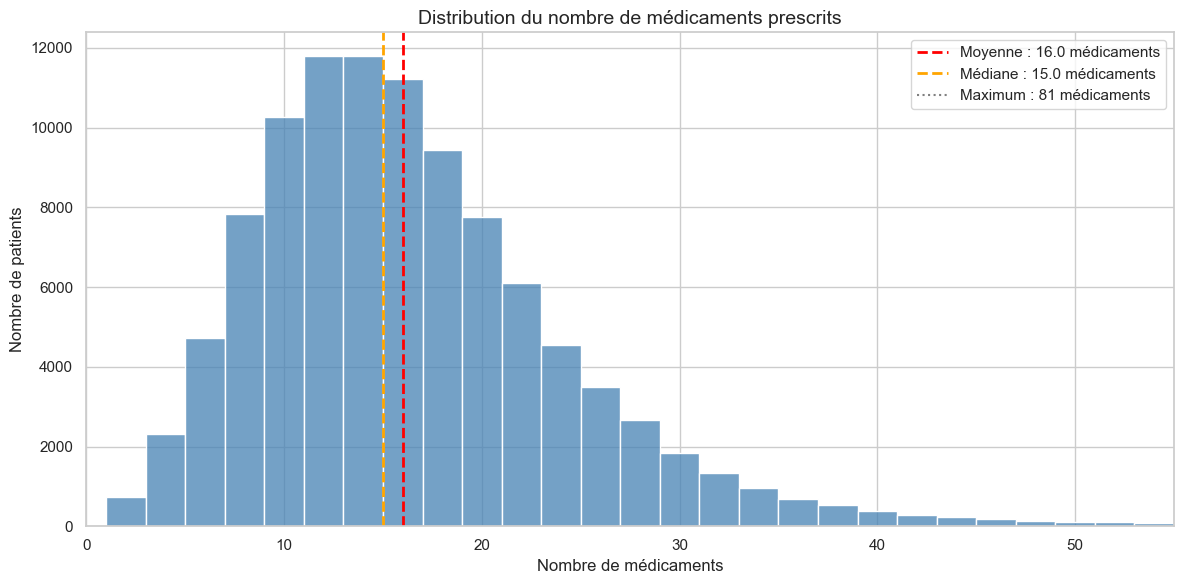

Moyenne  : 16.0 médicaments
Médiane  : 15.0 médicaments
Minimum  : 1 médicaments
Maximum  : 81 médicaments


In [13]:
# =============================================================
# CELLULE 10 — DISTRIBUTION DU NOMBRE DE MÉDICAMENTS
# =============================================================

plt.figure(figsize=(12, 6))

sns.histplot(df["num_medications"], bins=40,
             color="steelblue", edgecolor="white")

# Lignes moyenne et médiane
moyenne = df["num_medications"].mean()
mediane = df["num_medications"].median()

plt.axvline(moyenne, color="red", linestyle="--",
            linewidth=2, label=f"Moyenne : {moyenne:.1f} médicaments")
plt.axvline(mediane, color="orange", linestyle="--",
            linewidth=2, label=f"Médiane : {mediane:.1f} médicaments")
plt.axvline(df["num_medications"].max(), color="gray",
            linestyle=":", linewidth=1.5,
            label=f"Maximum : {df['num_medications'].max()} médicaments")

plt.title("Distribution du nombre de médicaments prescrits",
          fontsize=14)
plt.xlabel("Nombre de médicaments")
plt.ylabel("Nombre de patients")
plt.xlim(0, 55)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# --- Statistiques ---
print(f"Moyenne  : {moyenne:.1f} médicaments")
print(f"Médiane  : {mediane:.1f} médicaments")
print(f"Minimum  : {df['num_medications'].min()} médicaments")
print(f"Maximum  : {df['num_medications'].max()} médicaments")

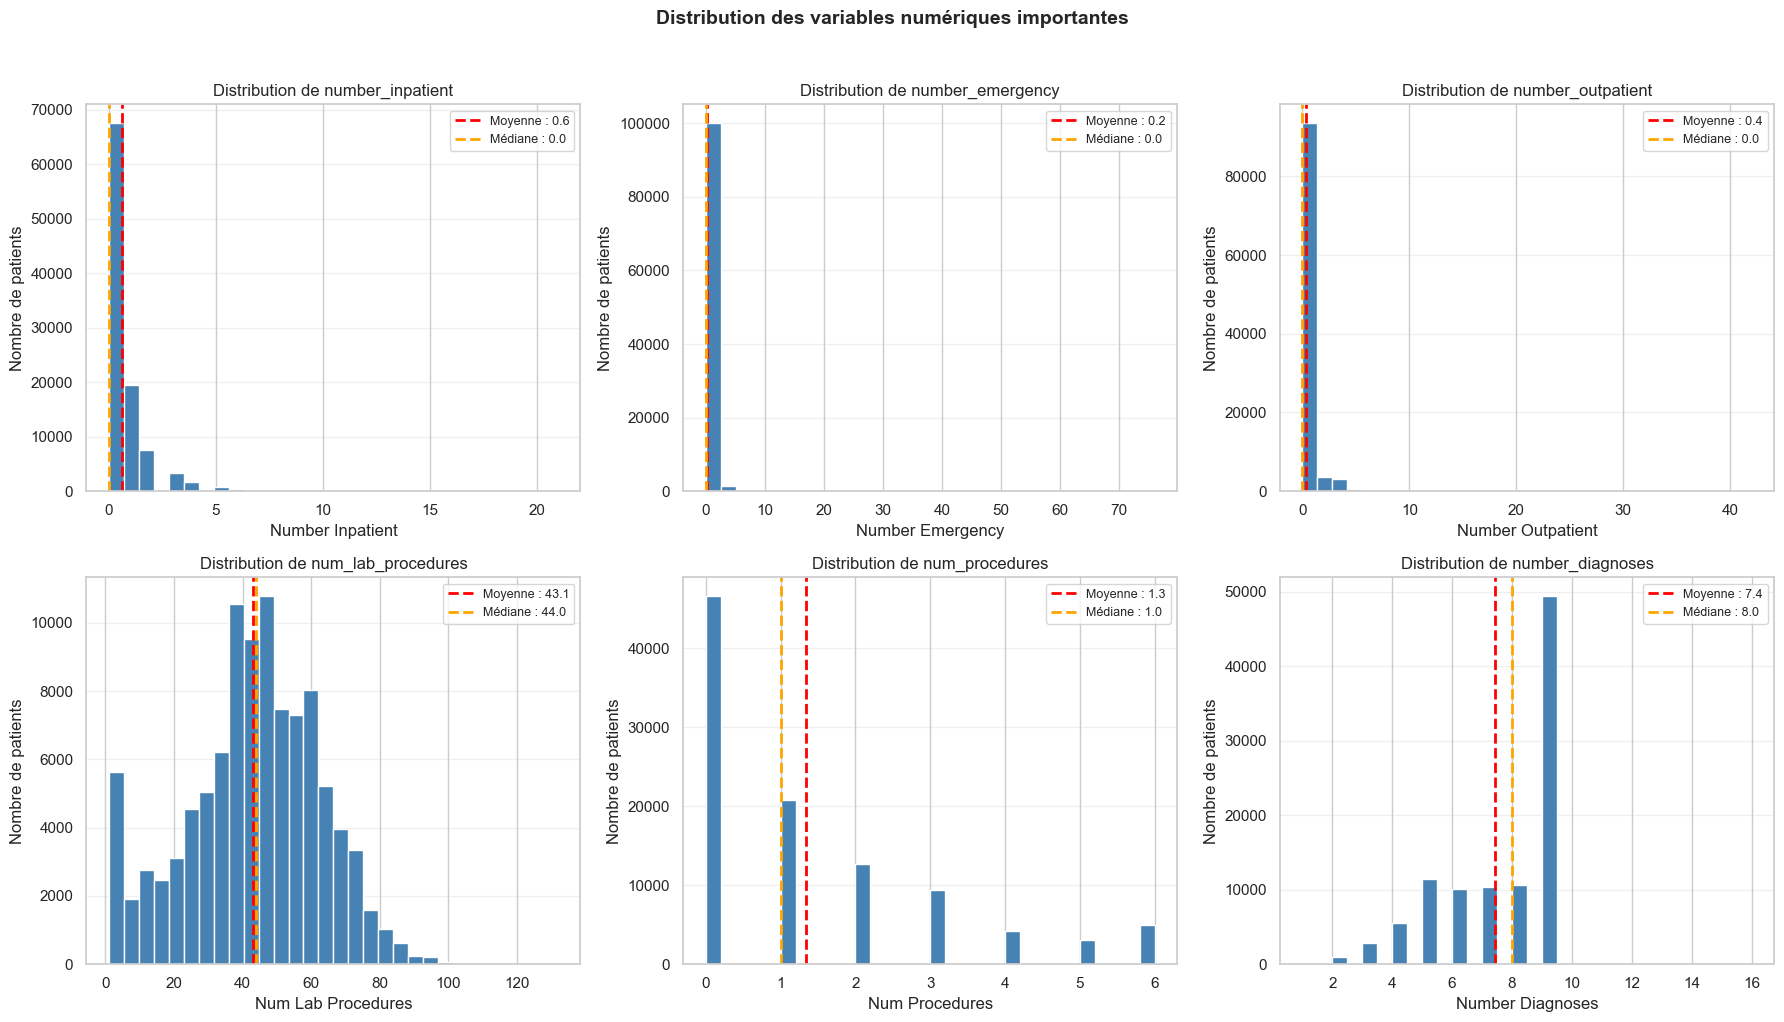

STATISTIQUES DES VARIABLES NUMÉRIQUES IMPORTANTES

number_inpatient
  Moyenne  : 0.64
  Médiane  : 0.00
  Maximum  : 21.00
  Minimum  : 0.00

number_emergency
  Moyenne  : 0.20
  Médiane  : 0.00
  Maximum  : 76.00
  Minimum  : 0.00

number_outpatient
  Moyenne  : 0.37
  Médiane  : 0.00
  Maximum  : 42.00
  Minimum  : 0.00

num_lab_procedures
  Moyenne  : 43.10
  Médiane  : 44.00
  Maximum  : 132.00
  Minimum  : 1.00

num_procedures
  Moyenne  : 1.34
  Médiane  : 1.00
  Maximum  : 6.00
  Minimum  : 0.00

number_diagnoses
  Moyenne  : 7.42
  Médiane  : 8.00
  Maximum  : 16.00
  Minimum  : 1.00


In [14]:
# =============================================================
# CELLULE — DISTRIBUTION DES VARIABLES NUMÉRIQUES IMPORTANTES
# =============================================================

# Variables numériques importantes identifiées
# par la corrélation et la connaissance médicale
variables_num = [
    "number_inpatient",
    "number_emergency",
    "number_outpatient",
    "num_lab_procedures",
    "num_procedures",
    "number_diagnoses"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(variables_num):
    ax = axes[i]

    # Histogramme
    ax.hist(df[var], bins=30,
            color="steelblue", edgecolor="white")

    # Moyenne et médiane
    moyenne = df[var].mean()
    mediane = df[var].median()

    ax.axvline(moyenne, color="red", linestyle="--",
               linewidth=2, label=f"Moyenne : {moyenne:.1f}")
    ax.axvline(mediane, color="orange", linestyle="--",
               linewidth=2, label=f"Médiane : {mediane:.1f}")

    ax.set_title(f"Distribution de {var}", fontsize=12)
    ax.set_xlabel(var.replace("_", " ").title())
    ax.set_ylabel("Nombre de patients")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Distribution des variables numériques importantes",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# --- Statistiques ---
print("=" * 60)
print("STATISTIQUES DES VARIABLES NUMÉRIQUES IMPORTANTES")
print("=" * 60)
for var in variables_num:
    print(f"\n{var}")
    print(f"  Moyenne  : {df[var].mean():.2f}")
    print(f"  Médiane  : {df[var].median():.2f}")
    print(f"  Maximum  : {df[var].max():.2f}")
    print(f"  Minimum  : {df[var].min():.2f}")

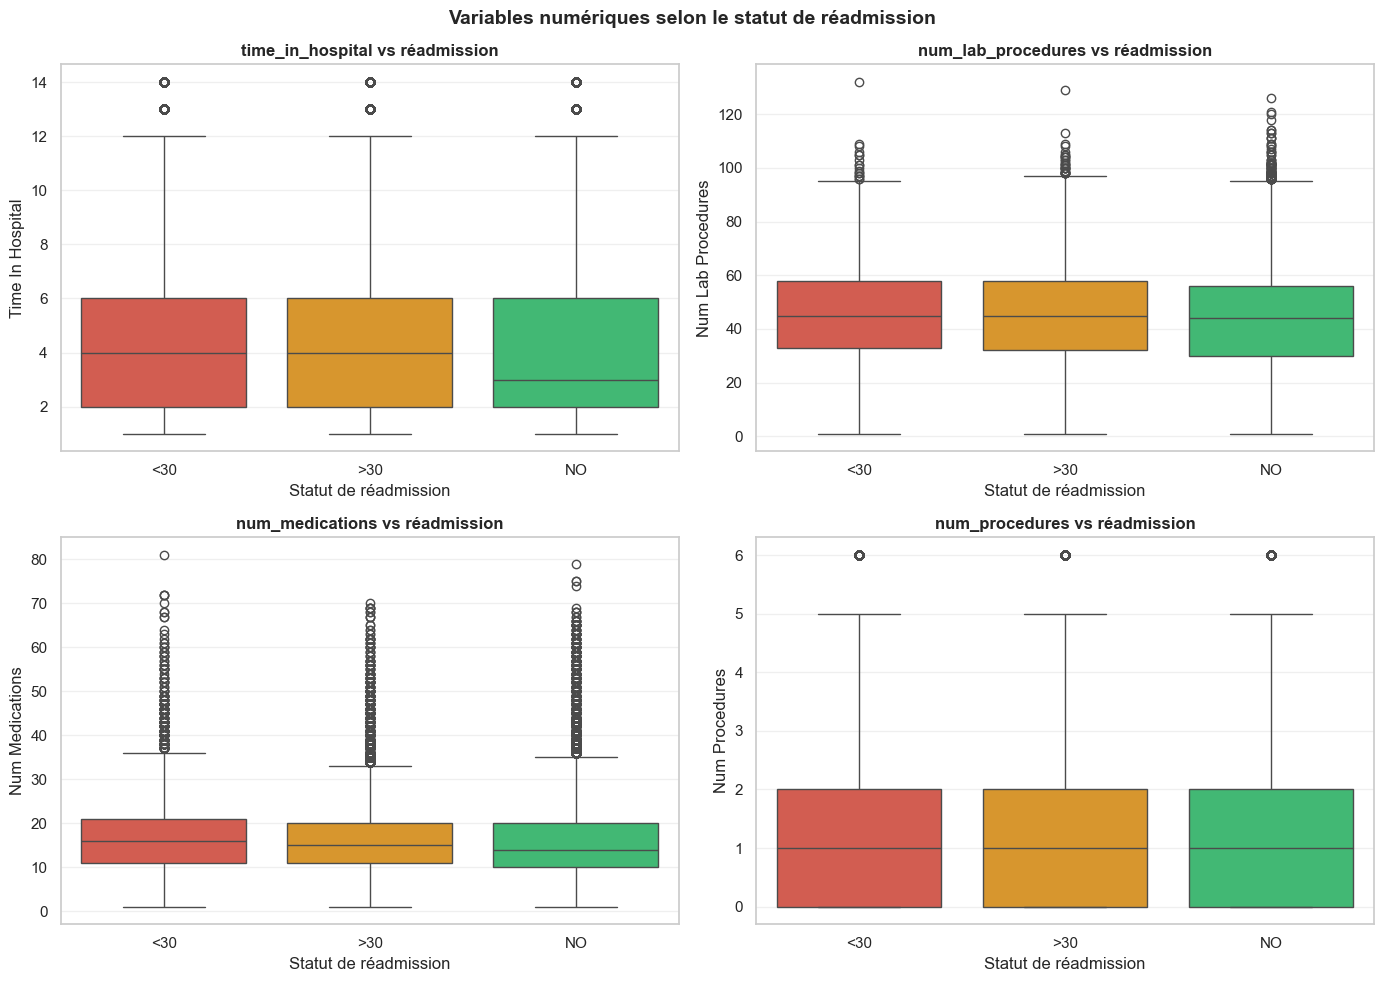

In [15]:
# =============================================================
# CELLULE 11 — VARIABLES NUMÉRIQUES VS CIBLE (BOXPLOTS)
# =============================================================

variables = ["time_in_hospital", "num_lab_procedures",
             "num_medications", "num_procedures"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(variables):
    ax = axes[i]

    sns.boxplot(data=df, x="readmitted", y=var,
                hue="readmitted",
                order=["<30", ">30", "NO"],
                palette={"<30": "#E74C3C",
                         ">30": "#F39C12",
                         "NO" : "#2ECC71"},
                legend=False,
                ax=ax)

    ax.set_title(f"{var} vs réadmission",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Statut de réadmission")
    ax.set_ylabel(var.replace("_", " ").title())
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Variables numériques selon le statut de réadmission",
             fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

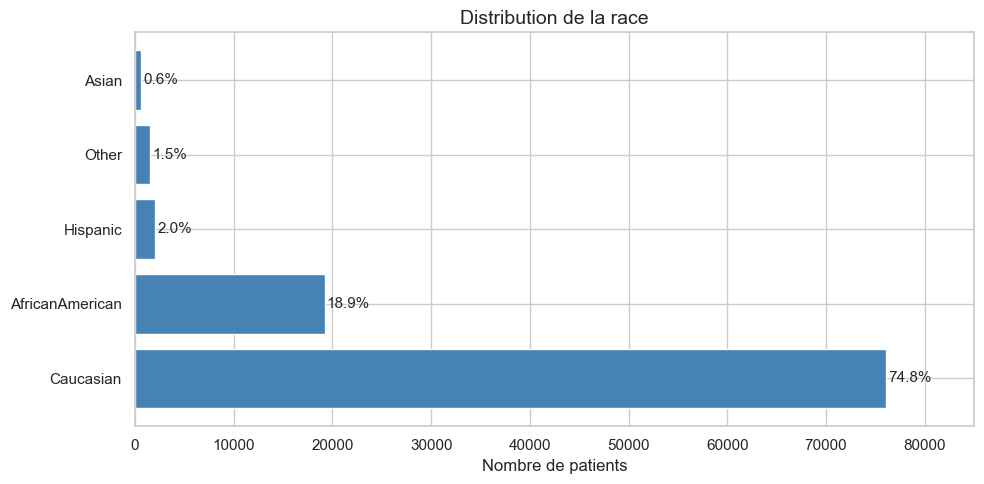

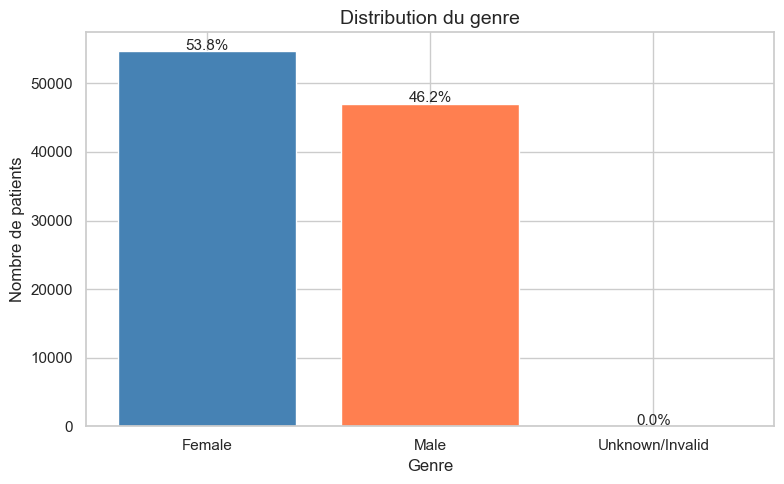

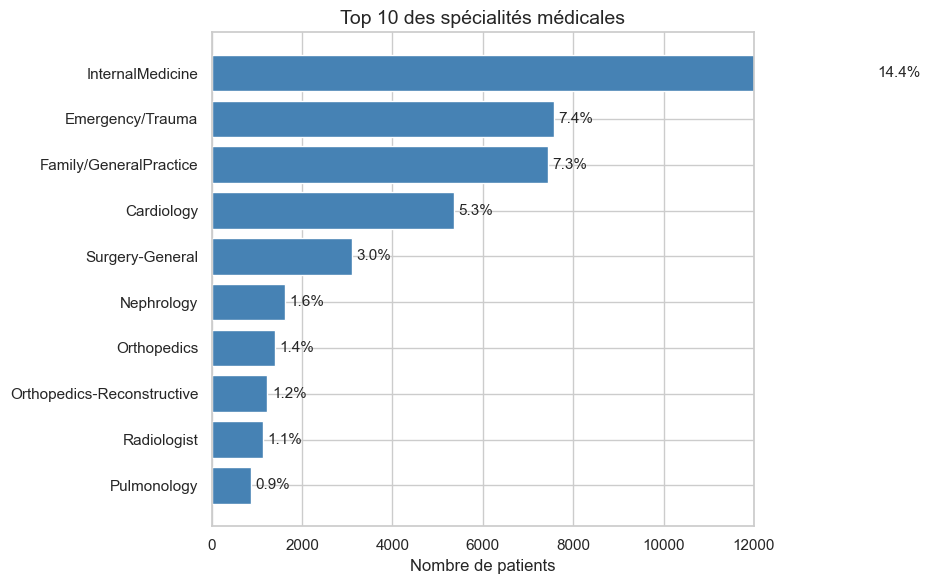

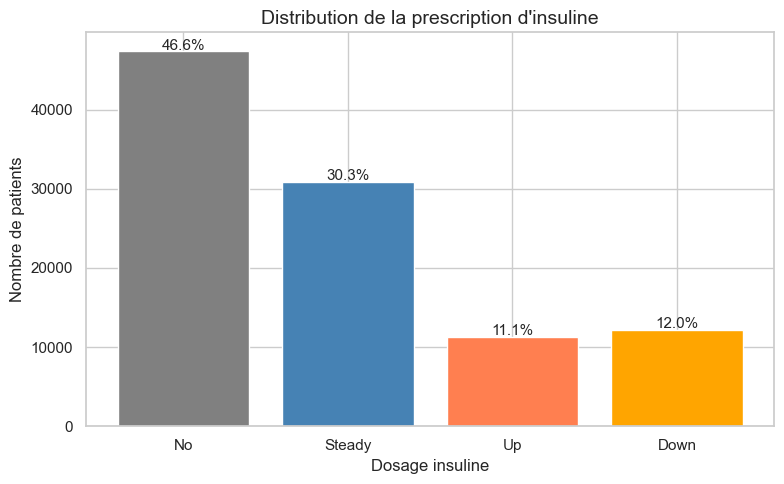

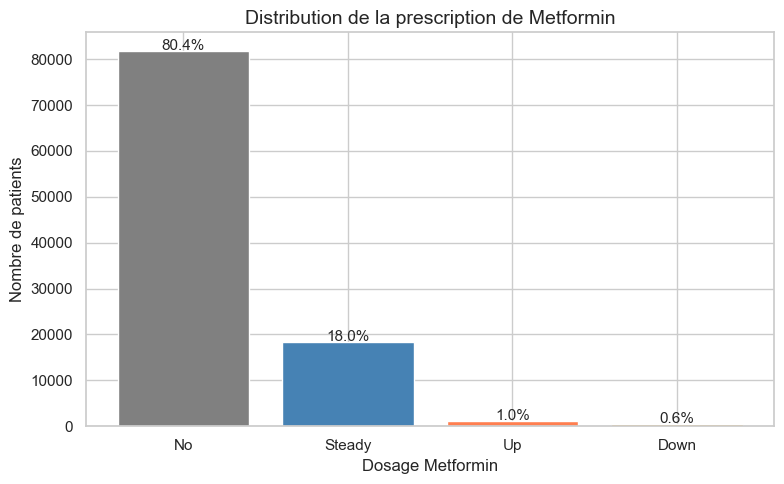

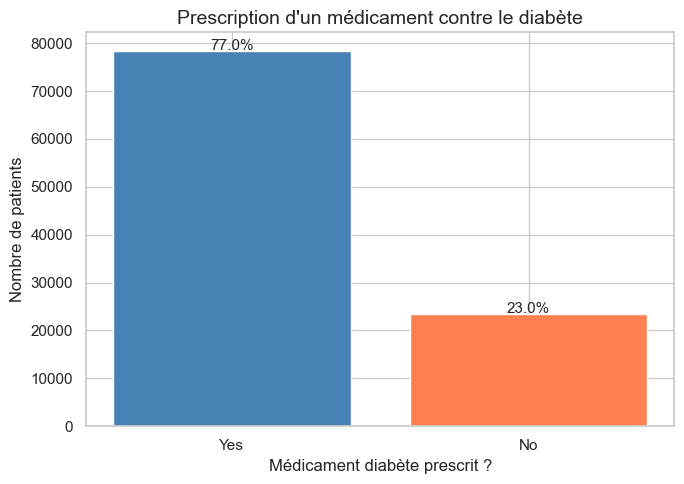

In [16]:
# =============================================================
# CELLULE 12 — DISTRIBUTION DES VARIABLES CATÉGORIELLES
# =============================================================

# --- Race ---
race_counts = df["race"].value_counts()
race_pct    = (race_counts / len(df) * 100).round(1)

plt.figure(figsize=(10, 5))
bars = plt.barh(race_counts.index, race_counts.values,
                color="steelblue", edgecolor="white")
for bar, pct in zip(bars, race_pct):
    plt.text(bar.get_width() + 200,
             bar.get_y() + bar.get_height() / 2,
             f"{pct}%", va="center", fontsize=11)
plt.title("Distribution de la race", fontsize=14)
plt.xlabel("Nombre de patients")
plt.xlim(0, 85000)
plt.tight_layout()
plt.show()

# --- Gender ---
gender_counts = df["gender"].value_counts()
gender_pct    = (gender_counts / len(df) * 100).round(1)

plt.figure(figsize=(8, 5))
bars = plt.bar(gender_counts.index, gender_counts.values,
               color=["steelblue", "coral", "gray"],
               edgecolor="white")
for bar, pct in zip(bars, gender_pct):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 200,
             f"{pct}%", ha="center", fontsize=11)
plt.title("Distribution du genre", fontsize=14)
plt.xlabel("Genre")
plt.ylabel("Nombre de patients")
plt.tight_layout()
plt.show()

# --- Medical Specialty ---
top_specialties = df["medical_specialty"].value_counts().head(10)
top_pct         = (top_specialties / len(df) * 100).round(1)

plt.figure(figsize=(10, 6))
bars = plt.barh(top_specialties.index[::-1],
                top_specialties.values[::-1],
                color="steelblue", edgecolor="white")
for bar, pct in zip(bars, top_pct[::-1]):
    plt.text(bar.get_width() + 100,
             bar.get_y() + bar.get_height() / 2,
             f"{pct}%", va="center", fontsize=11)
plt.title("Top 10 des spécialités médicales", fontsize=14)
plt.xlabel("Nombre de patients")
plt.xlim(0, 12000)
plt.tight_layout()
plt.show()

# --- Insulin ---
insulin_order  = ["No", "Steady", "Up", "Down"]
insulin_counts = df["insulin"].value_counts().reindex(insulin_order)
insulin_pct    = (insulin_counts / len(df) * 100).round(1)

plt.figure(figsize=(8, 5))
bars = plt.bar(insulin_order, insulin_counts.values,
               color=["gray", "steelblue", "coral", "orange"],
               edgecolor="white")
for bar, pct in zip(bars, insulin_pct):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 200,
             f"{pct}%", ha="center", fontsize=11)
plt.title("Distribution de la prescription d'insuline", fontsize=14)
plt.xlabel("Dosage insuline")
plt.ylabel("Nombre de patients")
plt.tight_layout()
plt.show()

# --- Metformin ---
metformin_order  = ["No", "Steady", "Up", "Down"]
metformin_counts = df["metformin"].value_counts().reindex(metformin_order)
metformin_pct    = (metformin_counts / len(df) * 100).round(1)

plt.figure(figsize=(8, 5))
bars = plt.bar(metformin_order, metformin_counts.values,
               color=["gray", "steelblue", "coral", "orange"],
               edgecolor="white")
for bar, pct in zip(bars, metformin_pct):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 200,
             f"{pct}%", ha="center", fontsize=11)
plt.title("Distribution de la prescription de Metformin", fontsize=14)
plt.xlabel("Dosage Metformin")
plt.ylabel("Nombre de patients")
plt.tight_layout()
plt.show()

# --- DiabetesMed ---
diabmed_counts = df["diabetesMed"].value_counts()
diabmed_pct    = (diabmed_counts / len(df) * 100).round(1)

plt.figure(figsize=(7, 5))
bars = plt.bar(diabmed_counts.index, diabmed_counts.values,
               color=["steelblue", "coral"], edgecolor="white")
for bar, pct in zip(bars, diabmed_pct):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 200,
             f"{pct}%", ha="center", fontsize=11)
plt.title("Prescription d'un médicament contre le diabète",
          fontsize=14)
plt.xlabel("Médicament diabète prescrit ?")
plt.ylabel("Nombre de patients")
plt.tight_layout()
plt.show()

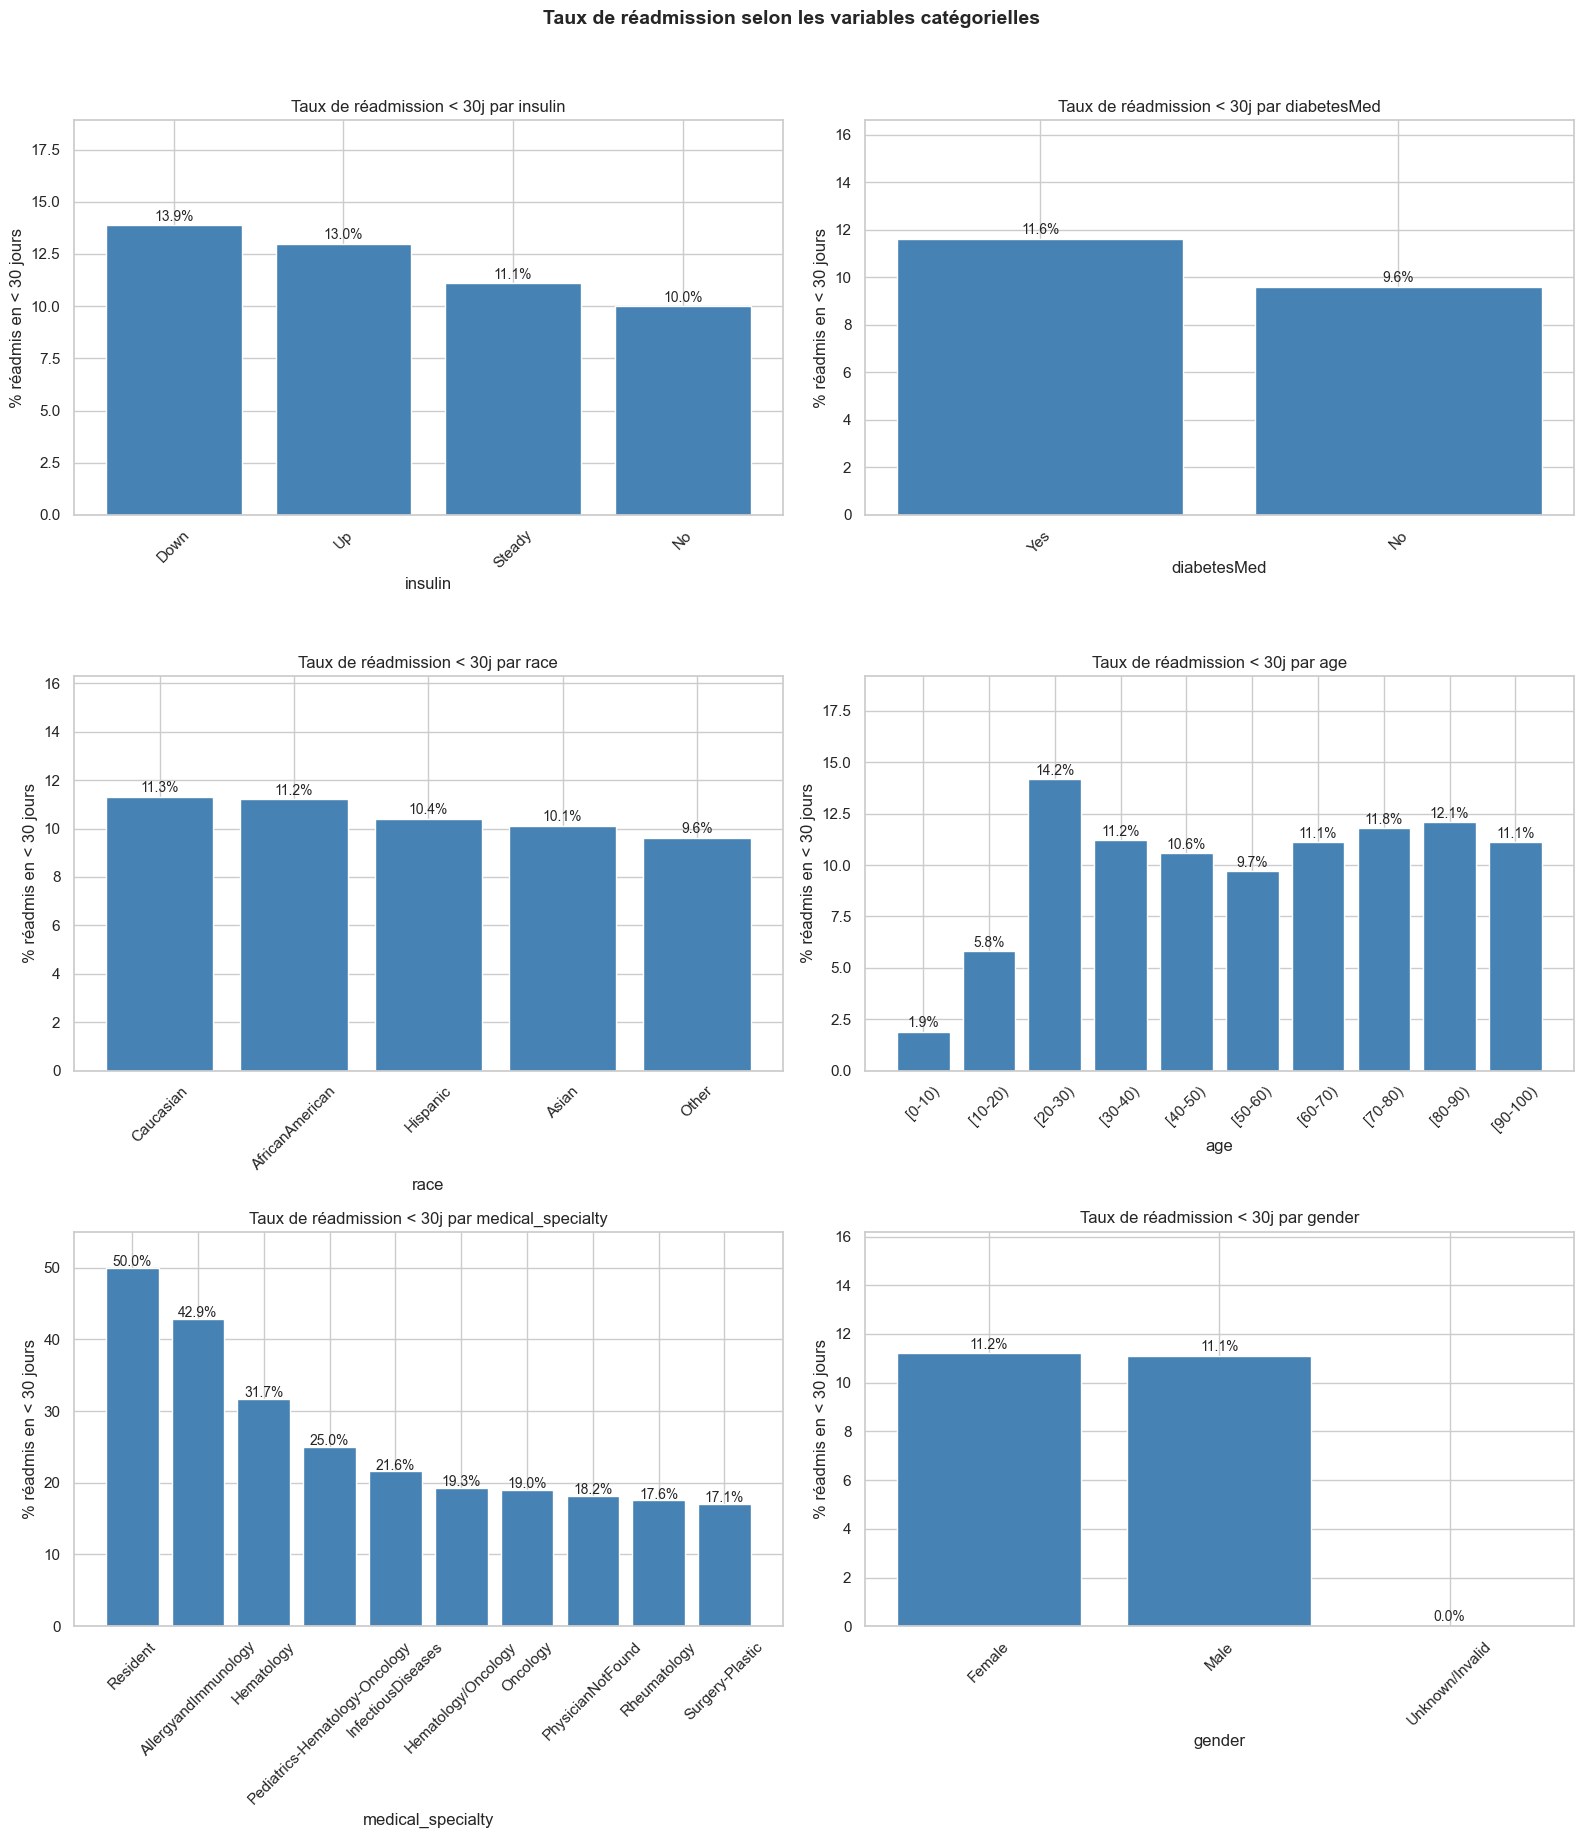

In [17]:
# =============================================================
# CELLULE 13 — VARIABLES CATÉGORIELLES VS CIBLE
# =============================================================
df["readmitted_binary"] = (df["readmitted"] == "<30").astype(int)

cat_vs_target = ["insulin", "diabetesMed", 
                 "race", "age",
                 "medical_specialty", "gender"]

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(cat_vs_target):
    ax = axes[i]

    taux = df.groupby(col)["readmitted_binary"].mean() * 100
    taux = taux.sort_values(ascending=False).round(1)

    # Tri chronologique pour l'âge
    if col == "age":
        age_order = ["[0-10)", "[10-20)", "[20-30)", "[30-40)",
                     "[40-50)", "[50-60)", "[60-70)", "[70-80)",
                     "[80-90)", "[90-100)"]
        taux = taux.reindex(age_order).dropna()

    # Top 10 pour medical_specialty
    if col == "medical_specialty":
        taux = taux.head(10)

    bars = ax.bar(taux.index, taux.values,
                  color="steelblue", edgecolor="white")

    for bar, val in zip(bars, taux.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.2,
                f"{val}%", ha="center", fontsize=10)

    ax.set_title(f"Taux de réadmission < 30j par {col}",
                 fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel("% réadmis en < 30 jours")
    ax.set_ylim(0, taux.max() + 5)
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Taux de réadmission selon les variables catégorielles",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

CORRÉLATION AVEC readmitted_binary
  number_inpatient                      0.165
  number_emergency                      0.061
  discharge_disposition_id              0.051
  number_diagnoses                       0.05
  time_in_hospital                      0.044
  num_medications                       0.038
  num_lab_procedures                     0.02
  number_outpatient                     0.019
  patient_nbr                           0.008
  admission_source_id                   0.006
  encounter_id                         -0.009
  admission_type_id                    -0.012
  num_procedures                       -0.012


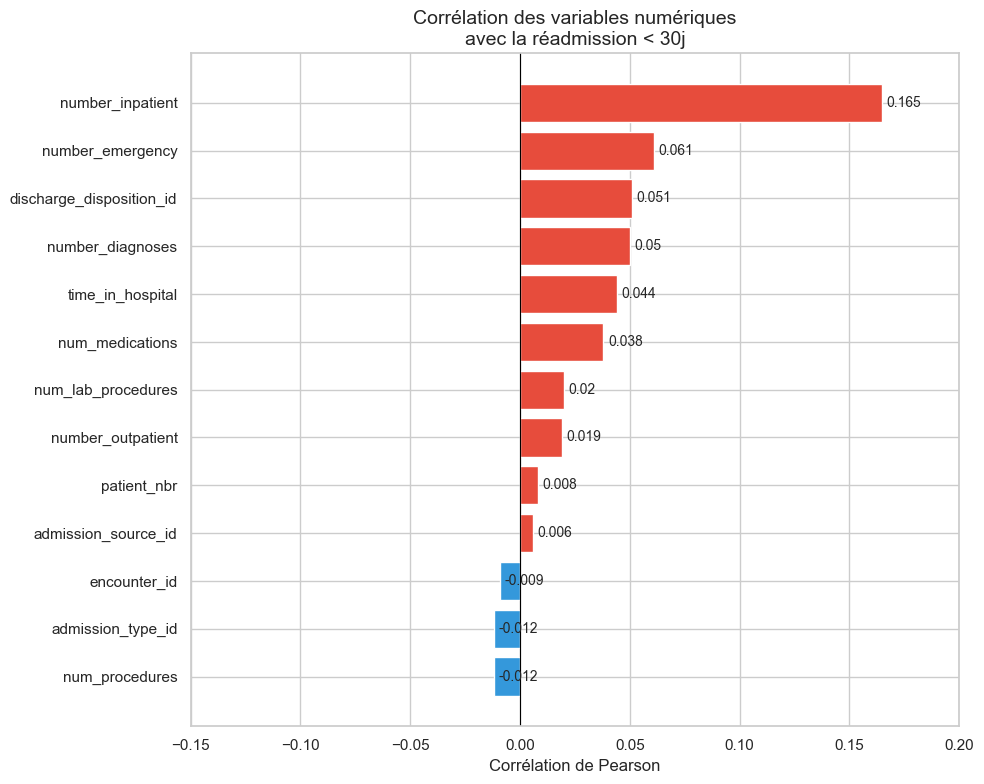

In [18]:
# =============================================================
# CELLULE 14 — CORRÉLATION DES VARIABLES NUMÉRIQUES VS CIBLE
# =============================================================

# Sélectionner uniquement les variables numériques
numeriques = df.select_dtypes(include=["int64", "float64"])

# Calculer la corrélation avec la variable cible
correlations = numeriques.corr()["readmitted_binary"] \
                         .drop("readmitted_binary") \
                         .sort_values(ascending=False) \
                         .round(3)

# --- Affichage texte ---
print("=" * 45)
print("CORRÉLATION AVEC readmitted_binary")
print("=" * 45)
for var, val in correlations.items():
    print(f"  {var:<35} {val:>7}")
print("=" * 45)

# --- Visualisation ---
plt.figure(figsize=(10, 8))

couleurs = ["#E74C3C" if v > 0 else "#3498DB"
            for v in correlations.values]

bars = plt.barh(correlations.index[::-1],
                correlations.values[::-1],
                color=couleurs[::-1],
                edgecolor="white")

# Ligne zéro
plt.axvline(x=0, color="black", linewidth=0.8)

# Valeurs sur les barres
for bar, val in zip(bars, correlations.values[::-1]):
    plt.text(bar.get_width() + 0.002,
             bar.get_y() + bar.get_height() / 2,
             f"{val}", va="center", fontsize=10)

plt.title("Corrélation des variables numériques\navec la réadmission < 30j",
          fontsize=14)
plt.xlabel("Corrélation de Pearson")
plt.xlim(-0.15, 0.20)
plt.tight_layout()
plt.show()

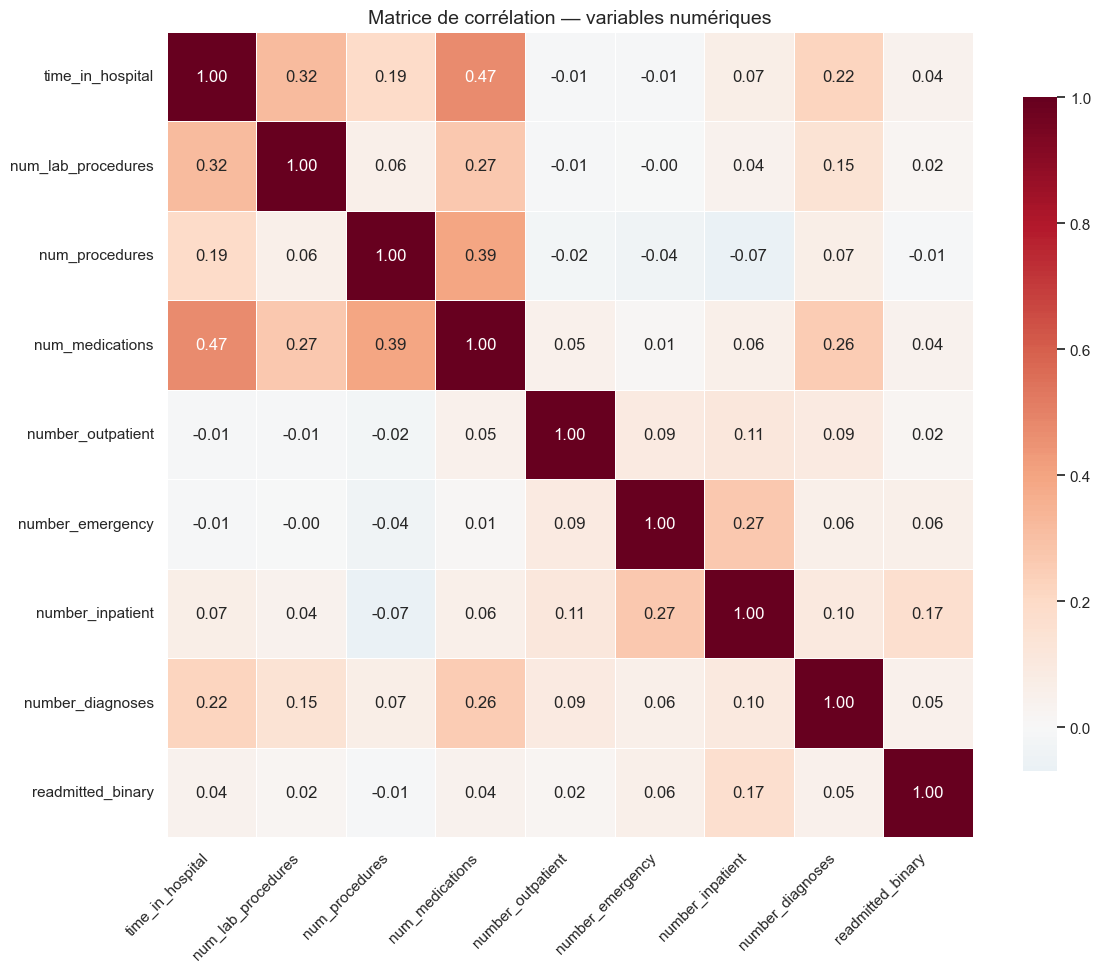

In [19]:
# =============================================================
# CELLULE 15 — MATRICE DE CORRÉLATION
# =============================================================

# On garde uniquement les variables numériques pertinentes
# pour que la matrice reste lisible
variables_importantes = [
    "time_in_hospital", "num_lab_procedures",
    "num_procedures", "num_medications",
    "number_outpatient", "number_emergency",
    "number_inpatient", "number_diagnoses",
    "readmitted_binary"
]

# Calcul de la matrice de corrélation
matrice = df[variables_importantes].corr().round(2)

# Visualisation
plt.figure(figsize=(12, 10))
sns.heatmap(matrice,
            annot=True,
            fmt=".2f",
            cmap="RdBu_r",
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title("Matrice de corrélation — variables numériques",
          fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Conclusions de l'exploration (EDA)

### 1. Dataset brut
- **101 766 séjours** hospitaliers, **50 variables**
- **Aucun doublon** détecté
- **71 518 patients uniques** (1.42 séjours/patient en moyenne)

### 2. Valeurs manquantes détectées
| Colonne | Manquant | Décision (notebook 02) |
|---|---|---|
| `weight` | 96.9% | Supprimer |
| `max_glu_serum` | 94.7% | Garder → encodage ordinal |
| `A1Cresult` | 83.3% | Garder → encodage ordinal |
| `medical_specialty` | 49.1% | Garder → top 10 + Autre |
| `payer_code` | 39.6% | Supprimer |
| `race` | 2.2% | Imputer par mode (sur train) |
| `diag_1/2/3` | < 2% | Groupement ICD-9 |

### 3. Variable cible
- `readmitted` → 3 valeurs : NO, >30, <30
- Binarisation dans notebook 02 **après le split**
- Déséquilibre attendu : ~89% négatifs / ~11% positifs

### 4. Observations clés
- Population majoritairement âgée (60-80 ans = 48%)
- Séjour moyen : 4.4 jours
- `number_inpatient` → variable la plus corrélée (0.165)

### 5. Variables prometteuses
**Numériques** : `number_inpatient`, `number_emergency`,
`time_in_hospital`, `num_medications`, `number_diagnoses`

**Catégorielles** : `insulin`, `diabetesMed`,
`medical_specialty`, `age`, `diag_1`

### 6. Prochaine étape
**Notebook 02** — Nettoyage structurel
